In [1]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
print(tf.__version__)

2.21.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
data = pd.read_csv('../datasets/acc_data.csv')
data.head()

,TIMESTAMP,INDEX,ACC_X,ACC_Y,ACC_Z,GESTURE
0,2.024110e+13,1,-365,26,905,1
1,2.024110e+13,1,-108,42,1007,1
2,2.024110e+13,1,-205,81,1003,1
3,2.024110e+13,1,-166,34,1003,1
4,2.024110e+13,1,-139,65,983,1


In [4]:
# fileName = "acc_data"
# file1 = pd.read_csv(f'{fileName}.csv')
# file1[' INDEX'] = (file1[' INDEX'] != file1[' INDEX'].shift()).cumsum()
# file1.to_csv(f'{fileName}_updated.csv', index=False)
# print(f"{fileName}_updated.csv created successfully!")

In [6]:
data = pd.read_csv('../datasets/acc_data_updated.csv')
data.head()

,TIMESTAMP,INDEX,ACC_X,ACC_Y,ACC_Z,GESTURE
0,2.024110e+13,1,-365,26,905,1
1,2.024110e+13,1,-108,42,1007,1
2,2.024110e+13,1,-205,81,1003,1
3,2.024110e+13,1,-166,34,1003,1
4,2.024110e+13,1,-139,65,983,1


In [7]:
data.shape

(200860, 6)

In [8]:
data.columns = data.columns.str.strip()

In [9]:
# data = data.drop(data[data.GESTURE == 'Up'].index)
# data = data.drop(data[data.GESTURE == 'Down'].index)

In [10]:
# for i in range(0, len(data), 1):
#     if(data['GESTURE'][i] == 1):
#         data['GESTURE'][i] = 'Forward'
#     elif(data['GESTURE'][i] == 2):
#         data['GESTURE'][i] = 'Back'
#     elif(data['GESTURE'][i] == 3):
#         data['GESTURE'][i] = 'Right'
#     elif(data['GESTURE'][i] == 4):
#         data['GESTURE'][i] = 'Left'
#     elif(data['GESTURE'][i] == 5):
#         data['GESTURE'][i] = 'Up'
#     elif(data['GESTURE'][i] == 6):
#         data['GESTURE'][i] = 'Down'
#     elif(data['GESTURE'][i] == 7):
#         data['GESTURE'][i] = 'Stop'

In [11]:
data.shape

(200860, 6)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200860 entries, 0 to 200859
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   TIMESTAMP  200860 non-null  float64
 1   INDEX      200860 non-null  int64  
 2   ACC_X      200860 non-null  int64  
 3   ACC_Y      200860 non-null  int64  
 4   ACC_Z      200860 non-null  int64  
 5   GESTURE    200860 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 9.2 MB


In [13]:
data.isnull().sum()

TIMESTAMP    0
INDEX        0
ACC_X        0
ACC_Y        0
ACC_Z        0
GESTURE      0
dtype: int64

In [14]:
data['GESTURE'].value_counts()

GESTURE
1    104778
2     96082
Name: count, dtype: int64

In [21]:
Fs = 50
gestures = data['GESTURE'].value_counts().index
gestures

Index([1, 2], dtype='int64', name='GESTURE')

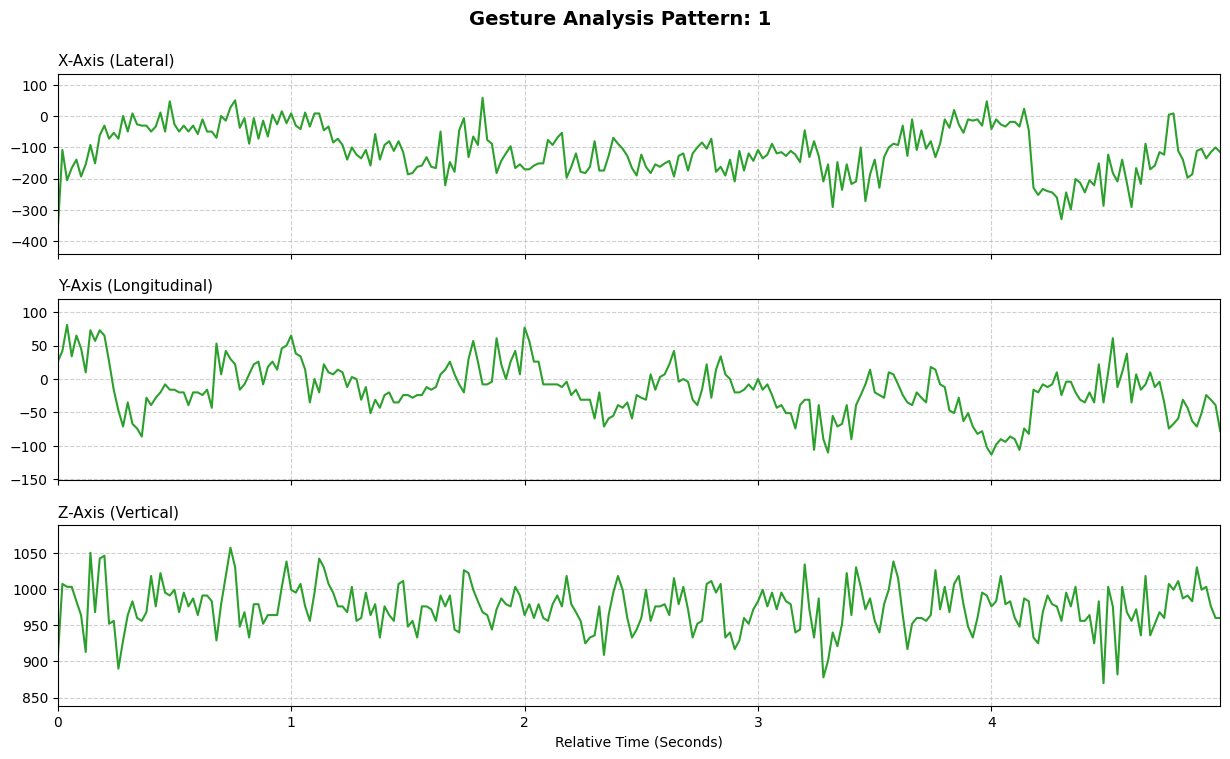

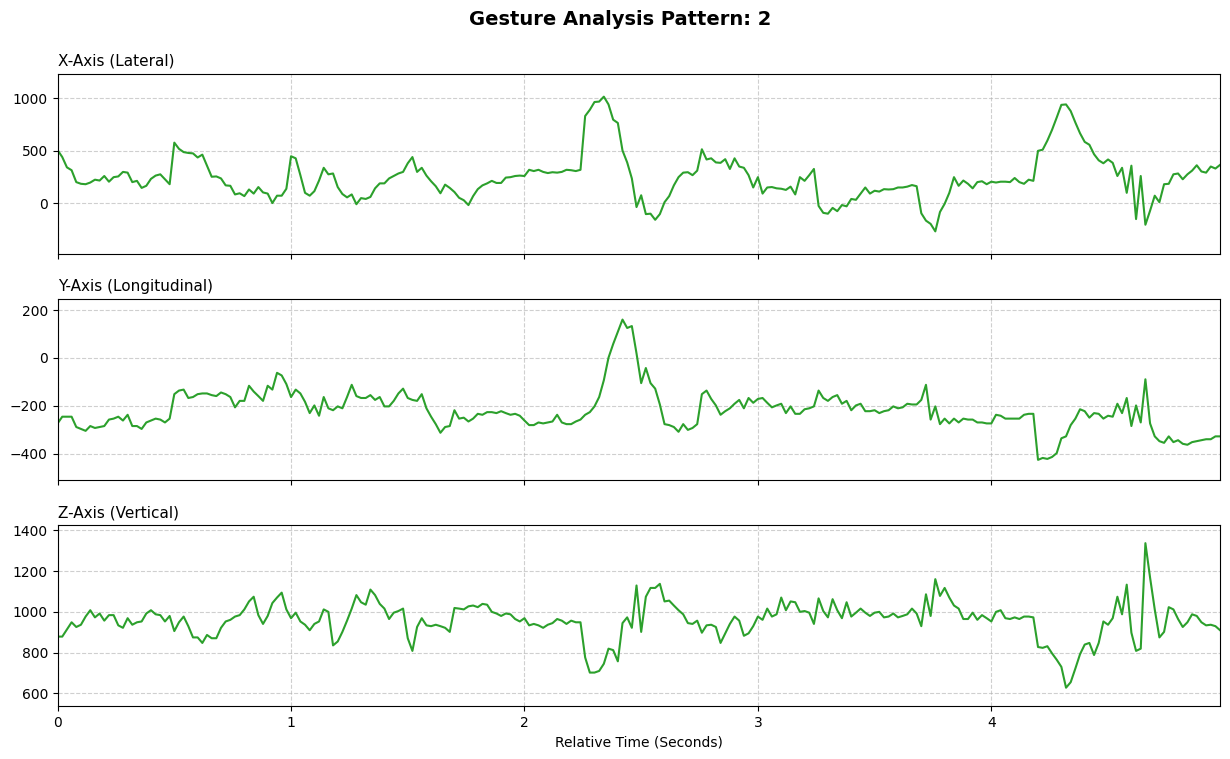

In [ ]:
def plot_gesture(activity, data):
    if data.empty:
        print(f"Skipping {activity}: No data found in this slice.")
        return

    time_steps = np.arange(len(data)) / Fs

    fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(15, 8), sharex=True)
    
    plot_axis(ax0, time_steps, data['ACC_X'], 'X-Axis (Lateral)')
    plot_axis(ax1, time_steps, data['ACC_Y'], 'Y-Axis (Longitudinal)')
    plot_axis(ax2, time_steps, data['ACC_Z'], 'Z-Axis (Vertical)', is_bottom=True)
    
    plt.subplots_adjust(hspace=0.25)
    fig.suptitle(f"Gesture Analysis Pattern: {activity}", fontsize=14, fontweight='bold')
    plt.subplots_adjust(top=0.90)
    plt.show()

def plot_axis(ax, x, y, title, is_bottom=False):
    ax.plot(x, y, color='tab:green', linewidth=1.5)
    ax.set_title(title, fontsize=11, loc='left')
    
    if is_bottom:
        ax.set_xlabel('Relative Time (Seconds)', fontsize=10)
    
    y_std = np.std(y) if np.std(y) > 0 else 1.0
    ax.set_ylim([np.min(y) - y_std, np.max(y) + y_std])
    ax.set_xlim([np.min(x), np.max(x)])
    ax.grid(True, linestyle='--', alpha=0.6)

for gesture in gestures:
    data_for_plot = data[(data['GESTURE'] == gesture)][:Fs*5]
    plot_gesture(gesture, data_for_plot)

In [24]:
df = data.drop(['INDEX', 'TIMESTAMP'], axis = 1).copy()
df.head()

,ACC_X,ACC_Y,ACC_Z,GESTURE
0,-365,26,905,1
1,-108,42,1007,1
2,-205,81,1003,1
3,-166,34,1003,1
4,-139,65,983,1


In [25]:
encoder = LabelEncoder()
df['GESTURE'] = encoder.fit_transform(df['GESTURE'])
df['GESTURE'].value_counts()

GESTURE
0    104778
1     96082
Name: count, dtype: int64

In [26]:
X = df[['ACC_X', 'ACC_Y', 'ACC_Z']]
y = df['GESTURE']

In [27]:
# scaler = StandardScaler()
# scaler2 = StandardScaler()
# temp = X
# scaler2.fit(temp)
# X = scaler.fit_transform(X)

scaled_X = pd.DataFrame(data = X, columns = ['ACC_X', 'ACC_Y', 'ACC_Z'])
scaled_X['GESTURE'] = y.values

# scaled_X.head()

In [28]:
# mean = scaler2.mean_
# std = scaler2.scale_

# print(mean)
# print(std)

In [29]:
encoder.classes_

array([1, 2])

In [30]:
import scipy.stats as stats

In [31]:
Fs = 25
frame_size = 25 #25
hop_size = 25 #12

In [32]:
def get_frames(df, frame_size, hop_size):

    N_FEATURES = 3

    frames = []
    labels = []
    for i in range(0, len(df) - frame_size, hop_size):
        x = df['ACC_X'].values[i: i + frame_size]
        y = df['ACC_Y'].values[i: i + frame_size]
        z = df['ACC_Z'].values[i: i + frame_size]
        
        # Retrieve the most often used label in this segment
        label = stats.mode(df['GESTURE'][i: i + frame_size])[0] #[0]
        frames.append([x, y, z])
        labels.append(label)

#     print(frames[0])
    # Bring the segments into a better shape
    frames = np.asarray(frames).reshape(-1, frame_size, N_FEATURES)
    labels = np.asarray(labels)
#     print(frames[0])

    return frames, labels

X, y = get_frames(scaled_X, frame_size, hop_size)

X.shape, y.shape

((8034, 25, 3), (8034,))

In [33]:
(3555*6)/40

533.25

In [34]:
# One hot encoding for categorical_crossentropy
# y_encoded = encoder.fit_transform(y)
# y_categorical = to_categorical(y_encoded)
# y_categorical.shape[1]

In [35]:
# X = X.reshape((X.shape[0], X.shape[1], 1, 3, 1))

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [37]:
X_train.shape, X_test.shape

((6427, 25, 3), (1607, 25, 3))

In [38]:
X_train[0].shape, X_test[0].shape

((25, 3), (25, 3))

In [39]:
# X_train = X_train.reshape(608, 30, 3, 1)
# X_test = X_test.reshape(153, 30, 3, 1)

In [40]:
X_train[0].shape, X_test[0].shape

((25, 3), (25, 3))

In [41]:
def plot_learningCurve(history, epochs):
  epoch_range = range(1, epochs+1)
  plt.plot(epoch_range, history.history['accuracy'])
  plt.plot(epoch_range, history.history['val_accuracy'])
  plt.title('Model accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

  plt.plot(epoch_range, history.history['loss'])
  plt.plot(epoch_range, history.history['val_loss'])
  plt.title('Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

In [42]:
from keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Conv3D, MaxPooling1D, LSTM
from tensorflow.keras.layers import ConvLSTM2D

In [43]:
# model = Sequential()
# model.add(Conv2D(16, (2, 2), activation = 'relu', input_shape = X_train[0].shape))
# model.add(Dropout(0.1))

# model.add(Conv2D(32, (2, 2), activation='relu'))
# model.add(Dropout(0.2))

# model.add(Flatten())

# model.add(Dense(64, activation = 'relu'))
# model.add(Dropout(0.5))

# model.add(Dense(7, activation='softmax'))
# model.summary()

In [44]:
# model = Sequential()

# model.add(Conv1D(32, kernel_size = 3, input_shape=(80,3), activation = 'relu'))

# model.add(MaxPooling1D(pool_size=2))

# model.add(Conv1D(64, kernel_size = 3, activation = 'relu'))
# model.add(MaxPooling1D(pool_size=2))
# model.add(Dropout(0.5))

# model.add(ConvLSTM2D(filters=128, kernel_size=(3,3),
#                      input_shape=(None, None, None, 1),
#                      padding='same', return_sequences=True))

# model.add(BatchNormalization())

# model.add(ConvLSTM2D(filters=128, kernel_size=(3,3),
#                      padding='same', return_sequences=True))

# model.add(BatchNormalization())

# model.add(ConvLSTM2D(filters=128, kernel_size=(3,3),
#                      padding='same', return_sequences=True))

# model.add(Conv1D(filters=64, kernel_size=(3, 3, 3),
#                activation='relu',
#                padding='same', data_format='channels_last'))

# model.add(Flatten())
# model.add(Dense(64, activation = 'relu'))
# model.add(Dropout(0.5))

# model.add(Dense(7, activation='softmax'))

In [45]:

# model = Sequential()

# model.add(ConvLSTM2D(filters=64, kernel_size=(1,2),
#                      input_shape=(50, 1, 3, 1), activation = 'relu',
#                      padding='same', return_sequences=True))
# # model.add(BatchNormalization())
# model.add(Dropout(0.3))

# model.add(ConvLSTM2D(filters=128, kernel_size=(1,2), activation = 'relu',
#                      padding='same', return_sequences=True))
# # model.add(BatchNormalization())
# model.add(Dropout(0.3))

# model.add(ConvLSTM2D(filters=64, kernel_size=(1,2), activation = 'relu',
#                      padding='same', return_sequences=False))
# # model.add(BatchNormalization())
# model.add(Dropout(0.3))

# model.add(Flatten())
# model.add(Dense(128, activation = 'relu'))
# model.add(Dropout(0.5))

# model.add(Dense(7, activation='softmax'))
# model.summary()

In [46]:
model = Sequential()

model.add(Conv1D(64, kernel_size = 3, input_shape=(25,3), activation = 'relu'))
# model.add(BatchNormalization())
model.add(Dropout(0.3))
# model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(64, kernel_size = 3, activation = 'relu'))
# model.add(BatchNormalization())
model.add(Dropout(0.3))
# model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(128, kernel_size = 3, activation = 'relu'))
# model.add(BatchNormalization())
model.add(Dropout(0.3))
# model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32))

model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.5))
# model.add(Dense(64, activation = 'relu'))
# model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))
model.summary()

e:\Work\ML\Directional-Motion-Detection\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 23, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 21, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 19, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 19, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 19, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,586 (920.26 KB)

 Trainable params: 235,586 (920.26 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(optimizer=Adam(learning_rate = 0.001), loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(X_train, y_train, epochs = 100, validation_data= (X_test, y_test), verbose=1)

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6182 - loss: 0.6211 - val_accuracy: 0.6752 - val_loss: 0.5699
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6929 - loss: 0.5487 - val_accuracy: 0.7144 - val_loss: 0.5344
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7103 - loss: 0.5366 - val_accuracy: 0.7113 - val_loss: 0.5295
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7212 - loss: 0.5269 - val_accuracy: 0.7063 - val_loss: 0.5439
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7255 - loss: 0.5246 - val_accuracy: 0.6801 - val_loss: 0.5401
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7283 - loss: 0.5178 - val_accuracy: 0.7187 - val_loss: 0.5303
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7360 - loss: 0.5104 - val_accuracy: 0.7206 - val_loss: 0.5296
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7316 - loss: 0.5202 - 

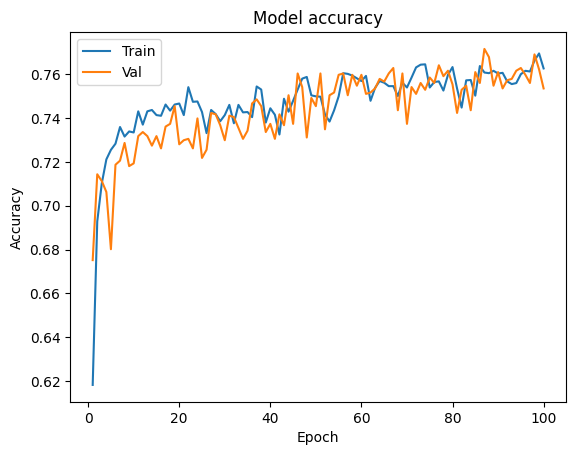

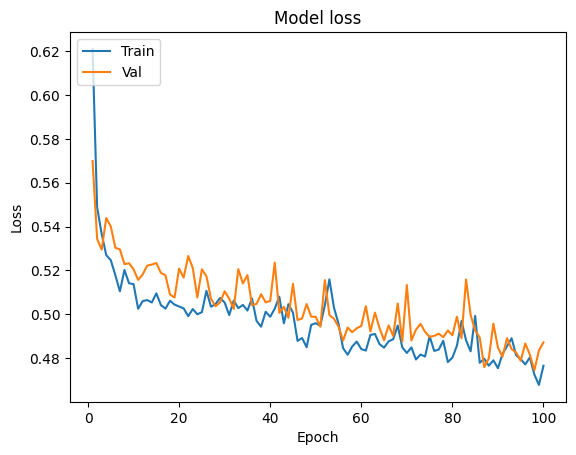

In [48]:
plot_learningCurve(history, 100)

In [49]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [50]:
y_pred = np.argmax(model.predict(X_test), axis=1)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [51]:
y_pred2 = model.predict(X_test)
np.argmax(y_pred2[0])

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


np.int64(1)

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

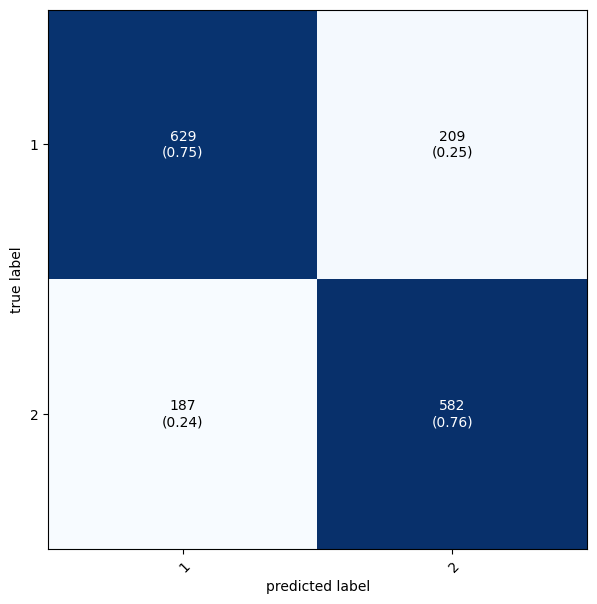

In [52]:
mat = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mat=mat, class_names=encoder.classes_, show_normed=True, figsize=(7,7))

In [53]:
model.save_weights('../models/main_model.weights.h5')

In [54]:
import pickle

In [55]:
with open('../models/main_model_pkl', 'wb') as files:
    pickle.dump(model, files)

In [ ]:
from tensorflow import lite
converter = lite.TFLiteConverter.from_keras_model(model)
converter.experimental_new_converter = True
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS,
tf.lite.OpsSet.SELECT_TF_OPS]
tflite_model = converter.convert()
with open("../models/Gesture_Classifier_model.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpaxzczo_r\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpaxzczo_r\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmpaxzczo_r'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 25, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2609183694992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607312387264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607415852752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607415852048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607416586512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607416584576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607416711424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607416712480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607416714592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2607416720224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  260746322348

In [57]:
y_pred.shape

(1607,)